# 02 — Construct the MD-derived Seitz table

This notebook uses only MD results plus the saved Argon scale.  It shows the raw
cavitation data, the homogeneous equation-of-state coverage used for interpolation,
the reduced-unit Seitz calculation, and its conversion to physical units.

REFPROP is deliberately not called here.


In [11]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from md_Helpers import (
    ArgonLJScale, ProjectPaths, SQLiteRunDatabase,
    calculate_cavitation_seitz, cavitation_dataframe,
    query_seitz_eos_states,
)

MD_REPO = Path.home() / "MDsims"
DATA_DIRECTORY = MD_REPO / "Argon" / "data"
SCALE_PATH = DATA_DIRECTORY / "argon_lj_scale.json"
assert SCALE_PATH.exists(), "Run notebook 01 first."

scale_record = json.loads(SCALE_PATH.read_text())
scale = ArgonLJScale(
    epsilon_over_kb_K=scale_record["epsilon_over_kB_K"],
    sigma_nm=scale_record["sigma_nm"],
    mass_u=scale_record["mass_u"],
    epsilon_over_kb_uncertainty_K=scale_record["epsilon_over_kB_uncertainty_K"],
    sigma_uncertainty_nm=scale_record["sigma_uncertainty_nm"],
)
database = SQLiteRunDatabase(ProjectPaths().database)
database.initialize()
scale.summary()


{'epsilon_over_kB_K': 128.5995507884122,
 'epsilon_over_kB_uncertainty_K': 0.04210981133938457,
 'epsilon_J': 1.775508411964705e-21,
 'epsilon_eV': 0.011081851865059125,
 'sigma_nm': 0.33585470206734763,
 'sigma_uncertainty_nm': 9.749997282766784e-06,
 'mass_u': 39.948,
 'mass_kg': 6.63352146325368e-26,
 'time_ps': np.float64(2.0528732475325384),
 'pressure_bar': 468.6713819873131,
 'density_mol_L': 43.83235439561305,
 'velocity_m_s': np.float64(163.60225964804692),
 'force_N': 5.286537306268438e-12}

## Raw cavitation and EOS selections


In [12]:
CAVITATION_FILTERS = {
    "Nsteps": [500_000],
    "Phase_Separation_Status": "Separated",
}
EOS_FILTERS = {
    "Nsteps": 200_000,
    "dt": 0.002,
    "Ensemble": "NVT",
}

cavitations = cavitation_dataframe(database, **CAVITATION_FILTERS)
eos = query_seitz_eos_states(database, n_cells=45, **EOS_FILTERS)

print("Cavitation rows:", len(cavitations))
print("Cavitation temperatures:", sorted(cavitations["Therm_kT"].unique()))
print("EOS rows:", len(eos))
print("EOS temperatures:", sorted(eos["Therm_kT"].unique()))

cavitations[[
    "Run_ID", "N_Cells", "Therm_kT", "Initial_Density", "BoxLength",
    "rho_liquid", "rho_liquid_unc", "Pressure_Mean",
    "PE_Per_Particle_Mean", "PE_Per_Particle_SEM",
]]


Cavitation rows: 69
Cavitation temperatures: [np.int64(1)]
EOS rows: 54
EOS temperatures: [np.float64(0.9), np.float64(0.95), np.float64(1.0)]


,Run_ID,N_Cells,Therm_kT,Initial_Density,BoxLength,rho_liquid,rho_liquid_unc,Pressure_Mean,PE_Per_Particle_Mean,PE_Per_Particle_SEM
0,20260918190731,30,1,0.587034,56.779373,0.614951,0.000554,0.015966,-3.819599,0.000835
1,20260918191538,30,1,0.5771,57.103832,0.615146,0.000579,0.020717,-3.811893,0.000457
2,20260918192601,20,1,0.580265,37.852913,0.607078,0.001094,0.006132,-3.76585,0.001073
3,20260918192848,20,1,0.570031,38.069221,0.609103,0.001112,0.003987,-3.747754,0.001615
4,20260918193606,25,1,0.584893,47.316143,0.610226,0.000752,0.012085,-3.802296,0.000579
...,...,...,...,...,...,...,...,...,...,...
64,20260922234846,40,1,0.598959,73.113831,0.617098,0.000371,0.021995,-3.852655,0.000362
65,20260922235712,45,1,0.5891,83.548599,0.618985,0.000306,0.026258,-3.851907,0.000458
66,20260923000637,45,1,0.580265,83.999008,0.619918,0.000308,0.02949,-3.847151,0.000268
67,20260923001014,45,1,0.571605,84.459282,0.619378,0.000311,0.028976,-3.837457,0.000267


In [13]:
eos[[
    "Run_ID", "Therm_kT", "Density_End", "Pressure_Mean", "Pressure_SEM",
    "PE_Per_Particle_Mean", "PE_Per_Particle_SEM",
]].sort_values(["Therm_kT", "Density_End"])


,Run_ID,Therm_kT,Density_End,Pressure_Mean,Pressure_SEM,PE_Per_Particle_Mean,PE_Per_Particle_SEM
0,20260917232048,0.9,0.65,-0.14778,0.000506,-4.146735,0.000133
2,20260917233701,0.9,0.66,-0.125499,0.000483,-4.205511,0.000125
31,20260918213001,0.9,0.665,-0.111674,0.000575,-4.235128,0.000134
1,20260917233136,0.9,0.67,-0.097091,0.000575,-4.265018,0.000135
30,20260918212434,0.9,0.675,-0.081378,0.000532,-4.295676,0.00013
3,20260917234222,0.9,0.68,-0.063444,0.00058,-4.325869,0.000122
29,20260918211900,0.9,0.685,-0.044204,0.000591,-4.356393,0.000138
4,20260917234747,0.9,0.69,-0.023433,0.000594,-4.387147,0.000138
28,20260918211326,0.9,0.695,-0.000577,0.000553,-4.417721,0.000108
5,20260917235316,0.9,0.7,0.024266,0.000578,-4.448289,0.000133


## Visualize EOS coverage before interpolation


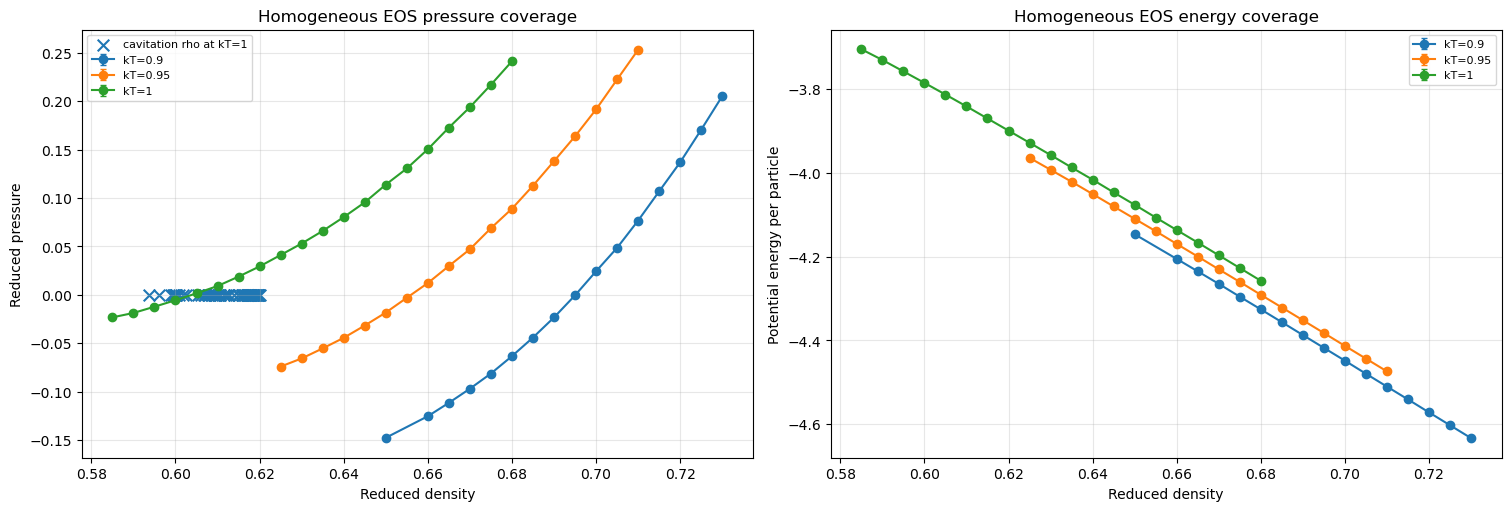

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5), constrained_layout=True)
for temperature, group in eos.groupby("Therm_kT"):
    group = group.sort_values("Density_End")
    axes[0].errorbar(group["Density_End"], group["Pressure_Mean"], yerr=group["Pressure_SEM"],
                     marker="o", capsize=2, label=f"kT={temperature:g}")
    axes[1].errorbar(group["Density_End"], group["PE_Per_Particle_Mean"],
                     yerr=group["PE_Per_Particle_SEM"], marker="o", capsize=2,
                     label=f"kT={temperature:g}")

for temperature, group in cavitations.groupby("Therm_kT"):
    axes[0].scatter(group["rho_liquid"], np.zeros(len(group)), marker="x", s=70,
                    label=f"cavitation rho at kT={temperature:g}")

axes[0].set(xlabel="Reduced density", ylabel="Reduced pressure", title="Homogeneous EOS pressure coverage")
axes[1].set(xlabel="Reduced density", ylabel="Potential energy per particle", title="Homogeneous EOS energy coverage")
for axis in axes:
    axis.legend(fontsize=8)
    axis.grid(alpha=0.3)
plt.show()


## Calculate the MD Seitz threshold in reduced units


In [15]:
results = calculate_cavitation_seitz(cavitations, eos)
reduced_columns = [
    "Run_ID", "Therm_kT", "Nc", "rho_c", "rho_liquid",
    "u_EOS", "P_EOS", "Q", "Q_uncertainty",
]
results[reduced_columns]


,Run_ID,Therm_kT,Nc,rho_c,rho_liquid,u_EOS,P_EOS,Q,Q_uncertainty
0,20260922151435,1.0,10679,0.529995,0.593626,-3.750632,-0.014137,1282.833701,131.310755
1,20260922152304,1.0,10692,0.526680,0.595974,-3.763455,-0.011057,1540.494646,132.338258
2,20260922150903,1.0,10828,0.505307,0.599026,-3.780195,-0.006985,2128.684492,144.924727
3,20260922150609,1.0,10795,0.519759,0.599312,-3.781761,-0.006604,1929.546854,135.688881
4,20260922151558,1.0,10887,0.504028,0.599644,-3.783581,-0.006161,2153.715215,147.160980
...,...,...,...,...,...,...,...,...,...
64,20260922235712,1.0,343563,0.589100,0.618985,-3.893577,0.027125,15079.980167,630.039820
65,20260923001014,1.0,344380,0.571605,0.619378,-3.895847,0.027953,21407.110105,628.803679
66,20260922222149,1.0,343547,0.584360,0.619608,-3.897175,0.028438,16821.083858,625.949964
67,20260922222452,1.0,344185,0.576002,0.619686,-3.897628,0.028603,19981.279877,627.472214


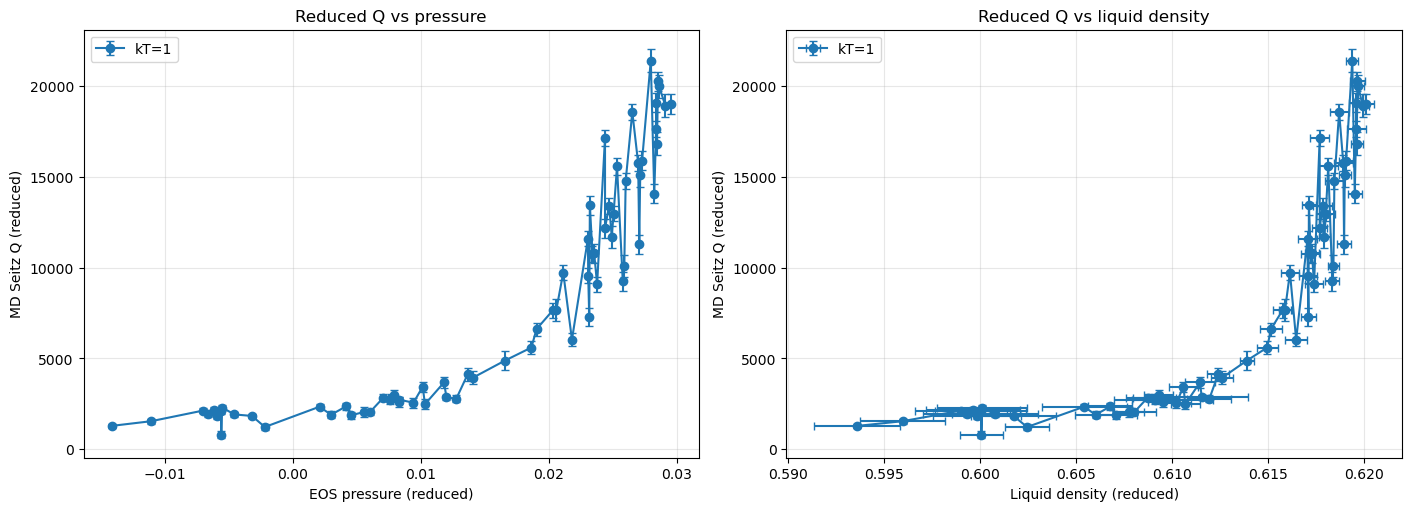

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
for temperature, group in results.groupby("Therm_kT"):
    group = group.sort_values("P_EOS")
    axes[0].errorbar(group["P_EOS"], group["Q"], yerr=group["Q_uncertainty"],
                     marker="o", capsize=3, label=f"kT={temperature:g}")
    axes[1].errorbar(group["rho_liquid"], group["Q"],
                     xerr=group["rho_liquid_uncertainty"], yerr=group["Q_uncertainty"],
                     marker="o", capsize=3, label=f"kT={temperature:g}")
axes[0].set(xlabel="EOS pressure (reduced)", ylabel="MD Seitz Q (reduced)", title="Reduced Q vs pressure")
axes[1].set(xlabel="Liquid density (reduced)", ylabel="MD Seitz Q (reduced)", title="Reduced Q vs liquid density")
for axis in axes:
    axis.legend()
    axis.grid(alpha=0.3)
plt.show()


## Convert the same states to physical Argon units


In [17]:
results["T_K"] = scale.temperature(results["Therm_kT"])
results["T_C"] = results["T_K"] - 273.15
results["P_bar"] = scale.pressure(results["P_EOS"], "bar")
results["P_psia"] = results["P_bar"] * 14.5037738
results["Q_MD_keV"] = scale.energy(results["Q"], "keV")
results["Q_MD_uncertainty_keV"] = scale.energy_uncertainty(
    results["Q"], results["Q_uncertainty"], "keV"
)
results["rho_liquid_mol_L"] = scale.number_density(results["rho_liquid"], "mol/L")
results["rho_liquid_uncertainty_mol_L"] = scale.number_density_uncertainty(
    results["rho_liquid"], results["rho_liquid_uncertainty"], "mol/L"
)

physical_columns = [
    "Run_ID", "Therm_kT", "T_K", "P_EOS", "P_bar", "P_psia",
    "rho_liquid_mol_L", "Q", "Q_MD_keV", "Q_MD_uncertainty_keV",
]
results[physical_columns]


,Run_ID,Therm_kT,T_K,P_EOS,P_bar,P_psia,rho_liquid_mol_L,Q,Q_MD_keV,Q_MD_uncertainty_keV
0,20260922151435,1.0,128.599551,-0.014137,-6.625739,-96.098217,26.020046,1282.833701,0.014216,0.001455
1,20260922152304,1.0,128.599551,-0.011057,-5.181991,-75.158422,26.122946,1540.494646,0.017072,0.001467
2,20260922150903,1.0,128.599551,-0.006985,-3.273490,-47.477954,26.256741,2128.684492,0.023590,0.001606
3,20260922150609,1.0,128.599551,-0.006604,-3.094968,-44.888712,26.269256,1929.546854,0.021383,0.001504
4,20260922151558,1.0,128.599551,-0.006161,-2.887417,-41.878439,26.283806,2153.715215,0.023867,0.001631
...,...,...,...,...,...,...,...,...,...,...
64,20260922235712,1.0,128.599551,0.027125,12.712794,184.383491,27.131571,15079.980167,0.167114,0.006982
65,20260923001014,1.0,128.599551,0.027953,13.100846,190.011707,27.148796,21407.110105,0.237230,0.006969
66,20260922222149,1.0,128.599551,0.028438,13.327956,193.305653,27.158877,16821.083858,0.186409,0.006937
67,20260922222452,1.0,128.599551,0.028603,13.405320,194.427733,27.162311,19981.279877,0.221430,0.006954


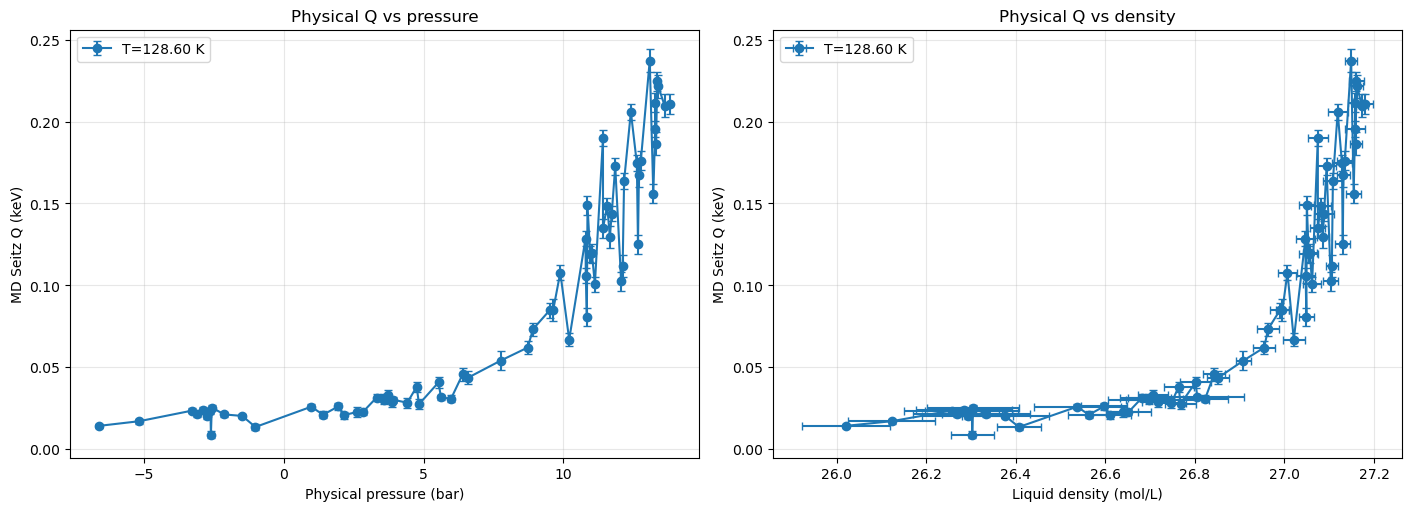

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
for temperature, group in results.groupby("T_K"):
    group = group.sort_values("P_bar")
    axes[0].errorbar(group["P_bar"], group["Q_MD_keV"], yerr=group["Q_MD_uncertainty_keV"],
                     marker="o", capsize=3, label=f"T={temperature:.2f} K")
    axes[1].errorbar(group["rho_liquid_mol_L"], group["Q_MD_keV"],
                     xerr=group["rho_liquid_uncertainty_mol_L"],
                     yerr=group["Q_MD_uncertainty_keV"], marker="o", capsize=3,
                     label=f"T={temperature:.2f} K")
axes[0].set(xlabel="Physical pressure (bar)", ylabel="MD Seitz Q (keV)", title="Physical Q vs pressure")
axes[1].set(xlabel="Liquid density (mol/L)", ylabel="MD Seitz Q (keV)", title="Physical Q vs density")
for axis in axes:
    axis.legend()
    axis.grid(alpha=0.3)
plt.show()


In [19]:
output_path = DATA_DIRECTORY / "md_seitz_states.csv"
results.to_csv(output_path, index=False)
print("Saved:", output_path)


Saved: /home/pnichols/MDsims/Argon/data/md_seitz_states.csv
